# Pipeline Completo VARMAX

Neste notebook vamos construir um pipeline completo:

- Carregar dados reais
- Preparar dados
- Treinar modelo VARMAX
- Salvar modelo
- Fazer previsões
- Integrar com Streamlit

👉 Este é o nível de produção

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from statsmodels.tsa.statespace.varmax import VARMAX

plt.style.use('dark_background')

In [5]:
#Carregando Dados
# Exemplo simulado (substituir pelos seus dados reais depois)
n = 300

df = pd.DataFrame({
    "custo": np.random.normal(100, 10, n).cumsum(),
    "veiculos": np.random.randint(5, 15, n),
    "distancia": np.random.normal(50, 5, n).cumsum()
})

df_exog = pd.DataFrame({
    "demanda": np.random.normal(1000, 50, n),
    "tempo_execucao": np.random.normal(30, 5, n)
})

df.head()

,custo,veiculos,distancia
0,104.753983,6,56.701260
1,199.360437,5,111.819516
2,303.581485,13,166.620712
3,400.480137,14,220.017692
4,489.733128,13,277.951708


In [7]:
# Pré-processaento
# Remover NaN
df = df.dropna()
df_exog = df_exog.loc[df.index]

# (Opcional) normalização
df_norm = (df - df.mean()) / df.std()
df_exog_norm = (df_exog - df_exog.mean()) / df_exog.std()

In [9]:
# Treinamento
modelo = VARMAX(df_norm, exog=df_exog_norm, order=(1,1))
resultado = modelo.fit(disp=False)

print(resultado.summary())

/home/isaac-kosloski/anaconda3/envs/varmax/lib/python3.11/site-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


                                   Statespace Model Results                                   
Dep. Variable:     ['custo', 'veiculos', 'distancia']   No. Observations:                  300
Model:                                    VARMAX(1,1)   Log Likelihood                1458.654
                                          + intercept   AIC                          -2851.309
Date:                                Thu, 26 Mar 2026   BIC                          -2729.084
Time:                                        03:37:11   HQIC                         -2802.394
Sample:                                             0                                         
                                                - 300                                         
Covariance Type:                                  opg                                         
Ljung-Box (L1) (Q):      35.21, 0.15, 1.32   Jarque-Bera (JB):   22914.78, 17.90, 0.23
Prob(Q):                  0.00, 0.70, 0.25   Prob(JB):    

In [10]:
# Salvando Modelo
with open("varmax_model.pkl", "wb") as f:
    pickle.dump(resultado, f)

In [11]:
# Carregando Modelo
with open("varmax_model.pkl", "rb") as f:
    modelo_carregado = pickle.load(f)

In [12]:
# Previsão
# Exógenas futuras (simulação)
exog_futuro = pd.DataFrame({
    "demanda": np.random.normal(1000, 50, 10),
    "tempo_execucao": np.random.normal(30, 5, 10)
})

# Normalizar com base no treino
exog_futuro_norm = (exog_futuro - df_exog.mean()) / df_exog.std()

previsao = modelo_carregado.forecast(steps=10, exog=exog_futuro_norm)

previsao

/home/isaac-kosloski/anaconda3/envs/varmax/lib/python3.11/site-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/home/isaac-kosloski/anaconda3/envs/varmax/lib/python3.11/site-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


,custo,veiculos,distancia
300,1.681047,-0.107296,1.678690
301,1.659501,-0.162520,1.656574
302,1.666652,-0.068835,1.663693
303,1.680051,-0.060805,1.677217
304,1.736879,0.021119,1.735067
305,1.673200,-0.279397,1.669991
306,1.597962,-0.280854,1.593209
307,1.577358,-0.116356,1.572212
308,1.610253,0.024467,1.605769
309,1.588605,-0.105821,1.583651


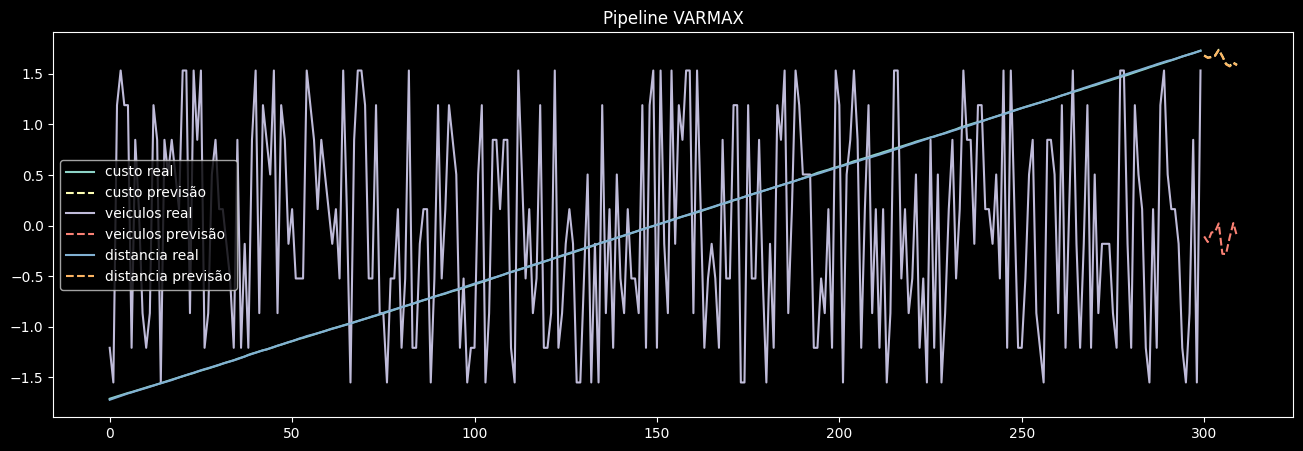

In [13]:
# Plot
plt.figure(figsize=(16,5))

for col in df.columns:
    plt.plot(df_norm[col], label=f"{col} real")
    plt.plot(range(len(df_norm), len(df_norm)+10),
             previsao[col],
             '--',
             label=f"{col} previsão")

plt.legend()
plt.title("Pipeline VARMAX")
plt.show()

## Conclusão

Agora você tem:

✔ Modelagem VARMAX  
✔ Diagnóstico completo  
✔ Pipeline de produção  
✔ Integração com dashboard  

🚀 Você está pronto para aplicar isso no seu projeto real